# SSD 配對交易滾動回測系統 (多參數網格搜索版)

這是一套架構非常完整且符合學術與業界實務標準的配對交易（Pairs Trading）滾動回測系統。系統主要參考了 Gatev et al. (2006) 等經典文獻的距離法（Distance Approach），並加入了動態 Z-Score、停損機制與多參數網格搜尋。

以下將針對系統的「四個主要階段（Class）」與「主程式」進行詳細的邏輯拆解與公式說明。

In [1]:
"""
SSD 配對交易滾動回測系統 (多參數網格搜索版)
核心功能：基於 SSD 與 Z-Score 的配對交易回測，支援多參數網格搜索與績效視覺化。
"""

import sqlite3
import warnings
import itertools
import os
from datetime import datetime
from pathlib import Path
from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.gridspec import GridSpec
import seaborn as sns 

warnings.filterwarnings("ignore")

## 1. 形成期階段（Class Formation：挑選配對）

**目的**：在過去一段時間（形成期，如 252 天）內，尋找走勢最相近、具備共整合潛力的股票對。

### 步驟與數學公式：

- **價格對數常態化（Normalize Prices）**：  
  為了消除不同股票絕對股價大小的影響，系統先取對數，再進行標準化（Z-score 轉換）。

  $$
  Z_{i,t} = \frac{\ln(P_{i,t}) - \mu_i}{\sigma_i}
  $$

  其中 $\mu_i$ 為平均值，$\sigma_i$ 為標準差。

- **計算平方差和（Sum of Squared Deviations, SSD）**：  
  在同產業（或全市場）內，將股票兩兩配對（Ticker A, Ticker B），計算它們常態化價格序列的歐式距離平方。SSD 越小，代表兩者走勢越貼合。

- **計算避險比例（Hedge Ratio, $\beta$）**：  
  使用 OLS（最小平方法）的解析解來計算 $\beta$。這裡將 B 視為自變數 $X$，A 視為應變數 $Y$。

- **計算價差特性（Spread Mean & Std）**：  
  根據求得的 $\beta$，計算形成期的價差（Spread）及其平均值與標準差，供靜態交易期使用。

- **篩選**：將所有配對依據 SSD 由小到大排序，選出前 `Top_N` 組進入交易期。

In [2]:
# ══════════════════════════════════════════════════════════════════════════════
# Class 1：Formation（形成期模組）
# ══════════════════════════════════════════════════════════════════════════════
class Formation:
    def __init__(self, price_df: pd.DataFrame, form_start: str, form_end: str, top_n: int = 20, sector_mapping: dict = None, min_tickers_for_pairing: int = 2):
        self.price_df = price_df.copy()
        self.form_start = form_start  
        self.form_end = form_end      
        self.top_n = top_n
        self.sector_mapping = sector_mapping or {}
        self.min_tickers_for_pairing = min_tickers_for_pairing

        self.normalized_df: pd.DataFrame = pd.DataFrame()
        self.mean_prices: pd.Series = pd.Series(dtype=float)
        self.std_prices: pd.Series = pd.Series(dtype=float)
        self.ssd_records: list = []
        self.selected_pairs: pd.DataFrame = pd.DataFrame()

    def normalize_prices(self) -> pd.DataFrame:
        log_prices = np.log(self.price_df)
        self.mean_prices = log_prices.mean()
        self.std_prices = log_prices.std()
        self.normalized_df = (log_prices - self.mean_prices) / self.std_prices
        return self.normalized_df

    def compute_ssd(self) -> pd.DataFrame:
        if self.normalized_df.empty:
            self.normalize_prices()

        tickers = self.normalized_df.columns.tolist()
        self.ssd_records = []

        sector_groups = {}
        if self.sector_mapping:
            for ticker in tickers:
                sector = self.sector_mapping.get(ticker, "Unknown")
                sector_groups.setdefault(sector, []).append(ticker)
        else:
            sector_groups["All_Market"] = tickers

        skipped_unknown_count = 0
        for sector, sector_tickers in sector_groups.items():
            if sector == "Unknown": 
                skipped_unknown_count = len(sector_tickers)
                continue 
            
            if len(sector_tickers) < self.min_tickers_for_pairing: continue
                
            for ticker_a, ticker_b in itertools.combinations(sector_tickers, 2):
                y_val = self.normalized_df[ticker_a].values
                x_val = self.normalized_df[ticker_b].values
                
                # SSD: 歸一化價格的平方差和
                ssd_value = np.sum((y_val - x_val) ** 2)
                
                # 向量化求 OLS 解析解
                cov_matrix = np.cov(x_val, y_val)
                var_x = cov_matrix[0, 0]
                cov_xy = cov_matrix[0, 1]
                
                beta = cov_xy / var_x if var_x > 1e-8 else 0.0
                
                # 依據文獻 Eq (3) 計算共整合 Spread: X_{2,t} - beta * X_{1,t}
                spread = y_val - beta * x_val
                spread_mean = np.mean(spread)
                spread_std = np.std(spread, ddof=1) if len(spread) > 1 else 0.0
                
                self.ssd_records.append({
                    "Form_Start": self.form_start, "Form_End": self.form_end, 
                    "Sector": sector, "Ticker_A": ticker_a, "Ticker_B": ticker_b,
                    "SSD": round(ssd_value, 6), "Hedge_Ratio": round(beta, 4),
                    "Spread_Mean": round(spread_mean, 6),
                    "Spread_Std": round(spread_std, 6)
                })

        if skipped_unknown_count > 0:
            print(f"  [Formation] 跳過 {skipped_unknown_count} 支未分類 (Unknown) 股票。")

        if not self.ssd_records: return pd.DataFrame()
        return pd.DataFrame(self.ssd_records).sort_values("SSD").reset_index(drop=True)

    def select_pairs(self) -> pd.DataFrame:
        ssd_df = self.compute_ssd()
        if ssd_df.empty:
            self.selected_pairs = pd.DataFrame()
            return self.selected_pairs

        selected = ssd_df.head(self.top_n).copy()
        selected["Rank"] = range(1, len(selected) + 1)

        mean_a_list, std_a_list, mean_b_list, std_b_list = [], [], [], []
        for _, row in selected.iterrows():
            mean_a_list.append(self.mean_prices[row["Ticker_A"]])
            std_a_list.append(self.std_prices[row["Ticker_A"]])
            mean_b_list.append(self.mean_prices[row["Ticker_B"]])
            std_b_list.append(self.std_prices[row["Ticker_B"]])
            
        selected["Log_Mean_A"] = mean_a_list
        selected["Log_Std_A"] = std_a_list
        selected["Log_Mean_B"] = mean_b_list
        selected["Log_Std_B"] = std_b_list

        self.selected_pairs = selected
        return self.selected_pairs

    def run(self) -> pd.DataFrame:
        self.normalize_prices()
        self.select_pairs()
        return self.selected_pairs

## 2. 交易期階段（Class Trading：執行交易）

**目的**：在未來的時間（交易期，如 126 天）內，監控選出配對的 Z-Score，並執行買賣與資金控管。

### 核心邏輯與數學公式：

系統支援兩種 Z-Score 計算模式，取決於 `zscore_window` 的設定：

- **模式一：靜態模式**（`zscore_window = 0`）  
  完全延用「形成期」計算出來的常數 $\beta$、Spread 平均值 $\mu$ 與標準差 $\sigma$。

- **模式二：動態模式**（`zscore_window > 0`，如 20 或 60 天）  
  因應市場結構改變，系統每天以過去 N 天的滾動視窗（Rolling Window）重新計算 OLS 迴歸。

  1. **動態 $\beta$ 與 $\mu$**：
     $$
     \beta_t, \mu_t = \text{OLS}(Y_{t-window:t}, X_{t-window:t})
     $$

  2. **動態價差（即 OLS 殘差）**：
     $$
     \text{Spread}_t = Y_t - \beta_t \cdot X_t - \mu_t
     $$

  3. **動態 Z-Score**：
     因 OLS 殘差平均值恆為 0，只需計算殘差的標準差（迴歸標準誤）。

### 交易訊號與資金部位（Position Sizing）：

- **進場**：
  - 當 $Z > $ 門檻：做空價差（Short A, Long B）。
  - 當 $Z < -$ 門檻：做多價差（Long A, Short B）。

- **部位分配（Beta-Neutral 權重）**：
  為保持市值與波動的對沖，投入資金依據 $\beta$ 的比例分配。

  $$
  \text{shares}_A = \frac{\text{capital} \times w}{\text{price}_A}, \quad \text{shares}_B = \frac{\text{capital} \times w \times \beta}{\text{price}_B}
  $$

- **出場**：
  - **停利（回歸均值）**：當持有多單且 $Z \leq 0$，或持有空單且 $Z \geq 0$。
  - **停損**：當單筆未實現虧損比例達到 `stop_loss_pct` 時強制平倉。
  - **結算強制平倉**：交易期最後一天（`PERIOD_END_EXIT`）強制作業。

In [3]:
# ══════════════════════════════════════════════════════════════════════════════
# Class 2：Trading（交易期模組）
# ══════════════════════════════════════════════════════════════════════════════
@dataclass
class PairState:
    """單一配對在模擬過程中的內部狀態"""
    position: int = 0
    shares_a: float = 0.0
    shares_b: float = 0.0
    entry_price_a: float = 0.0
    entry_price_b: float = 0.0
    realized_pnl: float = 0.0
    trade_entry_fee: float = 0.0
    days_held: int = 0
    is_stopped: bool = False
    cooldown_dir: int = 0
    prev_total_pnl: float = 0.0

class Trading:
    def __init__(self, price_df: pd.DataFrame, trade_dates: pd.DatetimeIndex, selected_pairs: pd.DataFrame, capital_per_pair: float, 
                 fee_rate: float, slippage_rate: float, stop_loss_pct: float, entry_z: float, exit_z: float, zscore_window: int, allow_reentry: bool = False,
                 zscore_clip: float = 10.0, min_spread_std: float = 1e-6):
        self.price_df = price_df.copy()
        self.trade_dates = trade_dates
        self.selected_pairs = selected_pairs
        self.capital_per_pair = capital_per_pair
        
        self.friction_rate = fee_rate + slippage_rate
        self.stop_loss_pct = stop_loss_pct
        self.entry_z = entry_z
        self.exit_z  = exit_z
        self.zscore_window = zscore_window
        self.allow_reentry = allow_reentry  
        self.zscore_clip = zscore_clip
        self.min_spread_std = min_spread_std

        self.all_trade_logs: list = []
        self.period_pnl: float = 0.0

    def _execute_entry(self, state: PairState, z: float, p_a: float, p_b: float, hedge_ratio: float) -> tuple[bool, float]:
        """處理進場邏輯與資金分配"""
        # 依據 2016 文獻，配對兩端資金投入比例為 1 : |beta|
        total_weight = 1.0 + abs(hedge_ratio)
        v_a = self.capital_per_pair * (1.0 / total_weight)
        v_b = self.capital_per_pair * (abs(hedge_ratio) / total_weight)
        
        if z > self.entry_z and state.cooldown_dir != -1:
            state.position = -1
            state.shares_a = -v_a / p_a
            state.shares_b = v_b / p_b
        elif z < -self.entry_z and state.cooldown_dir != 1:
            state.position = +1
            state.shares_a = v_a / p_a
            state.shares_b = -v_b / p_b
        else:
            return False, 0.0

        state.entry_price_a = p_a
        state.entry_price_b = p_b
        state.trade_entry_fee = (abs(state.shares_a) * p_a + abs(state.shares_b) * p_b) * self.friction_rate
        state.days_held = 0
        return True, -state.trade_entry_fee

    def _execute_close(self, state: PairState, current_trade_pnl: float, stop_loss: bool = False):
        """處理平倉與停損邏輯"""
        state.realized_pnl += current_trade_pnl 
        
        if stop_loss and not self.allow_reentry:
            state.is_stopped = True
        else:
            if self.allow_reentry:
                state.cooldown_dir = state.position  
                
        state.position = 0

    def _simulate_pair(self, sector: str, ticker_a: str, ticker_b: str, pair_rank: int, hedge_ratio: float, 
                       form_spread_mean: float, form_spread_std: float, log_mean_a: float, log_std_a: float, log_mean_b: float, log_std_b: float) -> list:
        if ticker_a not in self.price_df.columns or ticker_b not in self.price_df.columns: return []

        price_a, price_b = self.price_df[ticker_a].dropna(), self.price_df[ticker_b].dropna()
        common_idx = price_a.index.intersection(price_b.index)
        price_a, price_b = price_a.loc[common_idx], price_b.loc[common_idx]

        if len(price_a) < 5: return []

        log_p_a = np.log(price_a)
        log_p_b = np.log(price_b)

        norm_p_a = (log_p_a - log_mean_a) / log_std_a
        norm_p_b = (log_p_b - log_mean_b) / log_std_b
        
        if self.zscore_window == 0:
            # 靜態模式：使用形成期固定的 Beta 計算 Spread
            spread = norm_p_a - hedge_ratio * norm_p_b
            safe_std = max(form_spread_std, self.min_spread_std)
            zscore = np.clip((spread - form_spread_mean) / safe_std, -self.zscore_clip, self.zscore_clip)
            beta_series = pd.Series(hedge_ratio, index=common_idx)
        else:
            # 動態模式：逐日滾動計算最新的 Beta (Hedge Ratio) 與 Alpha (截距)
            roll_cov = norm_p_b.rolling(window=self.zscore_window).cov(norm_p_a)
            roll_var = norm_p_b.rolling(window=self.zscore_window).var()
            
            # 避免除以 0，計算出每日專屬的動態 Beta
            roll_beta = np.where(roll_var > 1e-8, roll_cov / roll_var, 0.0)
            roll_beta = pd.Series(roll_beta, index=common_idx)
            
            # 依據 OLS 公式推算動態 Alpha (截距)
            roll_mean_a = norm_p_a.rolling(window=self.zscore_window).mean()
            roll_mean_b = norm_p_b.rolling(window=self.zscore_window).mean()
            roll_alpha = roll_mean_a - roll_beta * roll_mean_b
            
            # Spread 在此被定義為迴歸的「殘差 (Residual)」: Y - Alpha - Beta * X
            spread = norm_p_a - roll_alpha - roll_beta * norm_p_b
            
            # 動態計算殘差標準差 (Standard Error of Regression) 
            # 數學公式: Var(e) = Var(A) - Beta * Cov(A, B)
            roll_var_a = norm_p_a.rolling(window=self.zscore_window).var()
            roll_res_var = roll_var_a - roll_beta * roll_cov
            roll_std = np.sqrt(np.maximum(roll_res_var, 0))
            
            # 因 OLS 殘差平均值恆為 0，故無需再減去平均，直接除以標準差即可得 Z-Score
            safe_std = np.maximum(roll_std, self.min_spread_std)
            zscore = np.clip(spread / safe_std, -self.zscore_clip, self.zscore_clip)
            beta_series = roll_beta

        # 將長度對齊至純交易期間
        valid_idx = common_idx.intersection(self.trade_dates)
        if len(valid_idx) == 0: return []
        
        price_a = price_a.loc[valid_idx]
        price_b = price_b.loc[valid_idx]
        zscore = zscore.loc[valid_idx]
        beta_series = beta_series.loc[valid_idx]

        dates_arr = valid_idx
        zscore_arr = zscore.values
        pa_arr = price_a.values
        pb_arr = price_b.values
        beta_arr = beta_series.values

        # 預建靜態常數字典 (Hedge_Ratio 不寫死，將於每日迴圈動態寫入)
        base_log = {
            "Sector": sector, "Pair_Rank": pair_rank,
            "Ticker_A": ticker_a, "Ticker_B": ticker_b,
            "Log_Mean_A": log_mean_a, "Log_Std_A": log_std_a,
            "Log_Mean_B": log_mean_b, "Log_Std_B": log_std_b
        }

        state = PairState()
        daily_logs = []

        for i in range(len(dates_arr)):
            date = dates_arr[i]
            z = 0.0 if np.isnan(zscore_arr[i]) else zscore_arr[i]
            p_a, p_b = pa_arr[i], pb_arr[i]
            
            # 獲取當日最新的 Beta，若因視窗不足產生 NaN，退回使用形成期常數 Beta
            c_beta = beta_arr[i] if not np.isnan(beta_arr[i]) else hedge_ratio

            unrealized_pnl = 0.0
            closed_trade_pnl = 0.0 
            daily_delta = 0.0
            current_status = "HOLD_CASH"

            if state.is_stopped:
                current_status = "STOPPED"
                log_record = base_log.copy()
                log_record.update({
                    "Date": date, "Price_A": round(p_a, 4), "Price_B": round(p_b, 4), 
                    "Hedge_Ratio": round(float(c_beta), 4), "ZScore": round(float(z), 4),
                    "Position": 0, "Unrealized_PnL": 0.0, "Realized_PnL": round(float(state.realized_pnl), 4), 
                    "Cumulative_PnL": round(float(state.realized_pnl), 4), "Status": current_status, 
                    "Trade_PnL": 0.0, "Days_Held": 0, "Daily_Delta": 0.0
                })
                daily_logs.append(log_record)
                continue

            if state.cooldown_dir == -1 and z <= self.exit_z:
                state.cooldown_dir = 0
            elif state.cooldown_dir == 1 and z >= -self.exit_z:
                state.cooldown_dir = 0

            if state.position != 0:
                state.days_held += 1
                raw_unrealized = state.shares_a * (p_a - state.entry_price_a) + state.shares_b * (p_b - state.entry_price_b)
                exit_fee_est = (abs(state.shares_a)*p_a + abs(state.shares_b)*p_b) * self.friction_rate
                
                current_trade_pnl = raw_unrealized - state.trade_entry_fee - exit_fee_est
                
                if self.stop_loss_pct > 0 and (-current_trade_pnl / self.capital_per_pair) >= self.stop_loss_pct:
                    self._execute_close(state, current_trade_pnl, stop_loss=True)
                    closed_trade_pnl = current_trade_pnl
                    current_status = "STOP_LOSS_TRIGGERED"
                else:
                    is_exit_short = (state.position == -1) and (z <= self.exit_z)  
                    is_exit_long  = (state.position == 1)  and (z >= -self.exit_z)  
                    
                    if is_exit_short or is_exit_long:
                        self._execute_close(state, current_trade_pnl, stop_loss=False)
                        closed_trade_pnl = current_trade_pnl
                        current_status = "EXIT"
                    else:
                        unrealized_pnl = raw_unrealized - state.trade_entry_fee 
                        current_status = "HOLDING"
            else: 
                if abs(z) > self.entry_z:
                    # 進場時，傳入當日最新的 c_beta 進行資金部位分配
                    entered, unrealized_pnl = self._execute_entry(state, z, p_a, p_b, c_beta)
                    if entered:
                        current_status = "ENTER_SHORT_A" if state.position == -1 else "ENTER_LONG_A"
                    else:
                        current_status = "HOLD_CASH (COOLDOWN)"
                else:
                    current_status = "HOLD_CASH"

            cumulative_pnl = state.realized_pnl + unrealized_pnl
            daily_delta = cumulative_pnl - state.prev_total_pnl
            state.prev_total_pnl = cumulative_pnl
            
            log_record = base_log.copy()
            log_record.update({
                "Date": date, "Price_A": round(p_a, 4), "Price_B": round(p_b, 4), 
                "Hedge_Ratio": round(float(c_beta), 4), "ZScore": round(float(z), 4),
                "Position": state.position, "Unrealized_PnL": round(float(unrealized_pnl), 4),
                "Realized_PnL": round(float(state.realized_pnl), 4), "Cumulative_PnL": round(float(cumulative_pnl), 4),
                "Status": current_status, "Trade_PnL": round(float(closed_trade_pnl), 4),
                "Days_Held": state.days_held, "Daily_Delta": round(float(daily_delta), 4)
            })
            daily_logs.append(log_record)

            if current_status in ["STOP_LOSS_TRIGGERED", "EXIT"]:
                state.days_held = 0 

            if state.is_stopped and i < len(dates_arr) - 1:
                for j in range(i + 1, len(dates_arr)):
                    rd = dates_arr[j]
                    r_z = 0.0 if np.isnan(zscore_arr[j]) else zscore_arr[j]
                    r_pa, r_pb = pa_arr[j], pb_arr[j]
                    r_beta = beta_arr[j] if not np.isnan(beta_arr[j]) else hedge_ratio
                    
                    stop_log = base_log.copy()
                    stop_log.update({
                        "Date": rd, "Price_A": round(r_pa, 4), "Price_B": round(r_pb, 4), 
                        "Hedge_Ratio": round(float(r_beta), 4), "ZScore": round(float(r_z), 4),
                        "Position": 0, "Unrealized_PnL": 0.0, "Realized_PnL": round(float(state.realized_pnl), 4), 
                        "Cumulative_PnL": round(float(state.realized_pnl), 4), "Status": "STOPPED", 
                        "Trade_PnL": 0.0, "Days_Held": 0, "Daily_Delta": 0.0
                    })
                    daily_logs.append(stop_log)
                break 

        if state.position != 0 and daily_logs:
            last_status = daily_logs[-1]["Status"]
            if last_status not in ("EXIT", "STOP_LOSS_TRIGGERED", "PERIOD_END_EXIT", "STOPPED"):
                pnl_before_last_day = daily_logs[-2]["Cumulative_PnL"] if len(daily_logs) > 1 else 0.0
                
                p_a_last, p_b_last = pa_arr[-1], pb_arr[-1]
                raw_unrealized_final = state.shares_a * (p_a_last - state.entry_price_a) + state.shares_b * (p_b_last - state.entry_price_b)
                exit_fee = (abs(state.shares_a)*p_a_last + abs(state.shares_b)*p_b_last) * self.friction_rate
                
                closed_trade_pnl = raw_unrealized_final - state.trade_entry_fee - exit_fee
                state.realized_pnl += closed_trade_pnl
                daily_delta = state.realized_pnl - pnl_before_last_day 
                
                daily_logs[-1].update({
                    "Status": "PERIOD_END_EXIT", 
                    "Realized_PnL": round(state.realized_pnl, 4), 
                    "Cumulative_PnL": round(state.realized_pnl, 4), 
                    "Unrealized_PnL": 0.0,
                    "Trade_PnL": round(closed_trade_pnl, 4),
                    "Daily_Delta": round(daily_delta, 4),
                    "Days_Held": state.days_held
                })

        return daily_logs

    def run(self) -> tuple:
        self.all_trade_logs = []
        for _, row in self.selected_pairs.iterrows():
            logs = self._simulate_pair(
                sector=row.get("Sector", "Unknown"), 
                ticker_a=row["Ticker_A"], 
                ticker_b=row["Ticker_B"], 
                pair_rank=row["Rank"], 
                hedge_ratio=float(row.get("Hedge_Ratio", 1.0)), 
                form_spread_mean=float(row.get("Spread_Mean", 0.0)), 
                form_spread_std=float(row.get("Spread_Std", 1.0)), 
                log_mean_a=float(row.get("Log_Mean_A", 0.0)), 
                log_std_a=float(row.get("Log_Std_A", 1.0)), 
                log_mean_b=float(row.get("Log_Mean_B", 0.0)), 
                log_std_b=float(row.get("Log_Std_B", 1.0))
            )
            self.all_trade_logs.extend(logs)
            
        if not self.all_trade_logs: 
            return pd.DataFrame(), pd.Series(dtype=float)
            
        log_df = pd.DataFrame(self.all_trade_logs)
        period_daily_delta = log_df.groupby("Date")["Daily_Delta"].sum()
        
        self.period_pnl = float(period_daily_delta.sum()) if not period_daily_delta.empty else 0.0
        
        return log_df, period_daily_delta

## 3. 績效評估階段（Class Performance：計算指標）

**目的**：彙總所有交易紀錄，計算財務工程標準的績效指標，並視覺化。

### 關鍵指標公式：

- **約定資本報酬率 (R_CC, Return on Committed Capital)**：
  基於總分配資金的報酬率。

- **動用資本報酬率 (R_EC, Return on Employed Capital)**：
  基於實際有觸發交易的配對資金報酬率（排除了完全沒進場的閒置資金）。

- **年化報酬率 (Annualized Return)**：
  $$
  \text{Annualized Return} = \left( \frac{\text{Total Return}}{\text{Days}} \right) \times 252
  $$

- **夏普比率 (Sharpe Ratio)**：
  衡量承受每單位風險的超額報酬。

- **最大回撤 (Max Drawdown, MDD)**：
  資金曲線從歷史最高點滑落的最大幅度。

In [4]:
# ══════════════════════════════════════════════════════════════════════════════
# Class 3：Performance（績效評估模組）
# ══════════════════════════════════════════════════════════════════════════════
class Performance:
    TRADING_DAYS_PER_YEAR = 252
    def __init__(self, initial_capital: float, output_dir: Path):
        self.initial_capital = initial_capital
        self.output_dir = output_dir
        self.output_dir.mkdir(parents=True, exist_ok=True)
        self.period_summaries, self.all_period_logs = [], []
        
        self._global_daily_delta = pd.Series(dtype=float) 
        self.equity_series = pd.Series(dtype=float)
        
        plt.rcParams.update({"figure.facecolor": "#0d1117", "axes.facecolor": "#161b22", "axes.edgecolor": "#30363d", 
                             "axes.labelcolor": "#c9d1d9", "axes.titlecolor": "#f0f6fc", "xtick.color": "#8b949e", 
                             "ytick.color": "#8b949e", "text.color": "#c9d1d9"})

    def set_zscore_params(self, entry_z: float, exit_z: float):
        self._entry_z, self._exit_z = entry_z, exit_z

    def add_period(self, period_start: str, period_end: str, trade_log_df: pd.DataFrame, period_daily_delta: pd.Series, capital_deployed: float, capital_per_pair: float):
        if trade_log_df.empty or period_daily_delta.empty: return
        
        if self._global_daily_delta.empty:
            self._global_daily_delta = period_daily_delta
        else:
            self._global_daily_delta = self._global_daily_delta.add(period_daily_delta, fill_value=0.0)

        period_pnl_abs = float(period_daily_delta.sum())
        
        pair_traded = trade_log_df.groupby(["Ticker_A", "Ticker_B"])["Position"].apply(lambda x: (x != 0).any())
        n_traded, n_nominated = int(pair_traded.sum()), len(pair_traded)
        r_cc = (period_pnl_abs / capital_deployed * 100) if capital_deployed > 0 else 0.0
        r_ec = (period_pnl_abs / (n_traded * capital_per_pair) * 100) if n_traded > 0 else 0.0

        exits = trade_log_df[trade_log_df["Status"].isin(["EXIT", "STOP_LOSS_TRIGGERED", "PERIOD_END_EXIT"])]
        exits = exits[exits["Trade_PnL"] != 0] 
        trade_count = len(exits)
        win_trades = len(exits[exits["Trade_PnL"] > 0])
        gross_profit = exits[exits["Trade_PnL"] > 0]["Trade_PnL"].sum()
        gross_loss = abs(exits[exits["Trade_PnL"] < 0]["Trade_PnL"].sum())
        
        stop_losses = len(trade_log_df[trade_log_df["Status"] == "STOP_LOSS_TRIGGERED"])
        forced_exits = len(trade_log_df[trade_log_df["Status"] == "PERIOD_END_EXIT"])

        payoff_ratio = (gross_profit / gross_loss) if gross_loss > 0 else np.nan
        avg_holding_days = exits["Days_Held"].mean() if trade_count > 0 else 0.0

        log_copy = trade_log_df.copy()
        log_copy["Period_Start"], log_copy["Period_End"] = period_start, period_end
        self.all_period_logs.append(log_copy)

        self.period_summaries.append({
            "Period_Start": period_start, "Period_End": period_end, "Capital_Deployed": round(capital_deployed, 2), 
            "Period_PnL_USD": round(period_pnl_abs, 2), "R_CC_Pct": round(r_cc, 4), "R_EC_Pct": round(r_ec, 4),
            "Nominated_Pairs": n_nominated, "Traded_Pairs": n_traded,
            "Trade_Count": trade_count, "Win_Trades": win_trades, 
            "Stop_Loss_Count": stop_losses, "Forced_Exit_Count": forced_exits,
            "Avg_Hold_Days": round(avg_holding_days, 1), "Payoff_Ratio": payoff_ratio
        })

    def _plot_summary(self, report: dict):
        fig, ax = plt.subplots(figsize=(8, 6))
        fig.patch.set_facecolor("#0d1117")
        ax.axis("off")
        
        cell_text = [[k, v] for k, v in report.items()]
        table = ax.table(cellText=cell_text, colLabels=["Metric", "Value"], loc="center", cellLoc="left")
        table.auto_set_font_size(False)
        table.set_fontsize(11)
        table.scale(1, 2)
        
        for (row, col), cell in table.get_celld().items():
            cell.set_edgecolor("#30363d")
            if row == 0:
                cell.set_facecolor("#21262d")
                cell.set_text_props(color="#f0f6fc", weight="bold")
            else:
                cell.set_facecolor("#161b22")
                cell.set_text_props(color="#c9d1d9")
            if col == 0: cell.set_width(0.6)
            else: cell.set_width(0.4)
            
        ax.set_title("📊 Performance Summary", color="#f0f6fc", fontsize=14, fontweight="bold", pad=15)
        plt.tight_layout(rect=[0, 0, 1, 0.96])
        fig.savefig(self.output_dir / "summary_report.png", dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
        plt.close(fig)

    def generate_report(self, quiet=True) -> dict:
        if not self.period_summaries or self._global_daily_delta.empty: 
            return {}

        self._global_daily_delta.sort_index(inplace=True)
        
        self.equity_series = self.initial_capital + self._global_daily_delta.cumsum()

        final_eq = self.equity_series.iloc[-1]
        pnl_abs = final_eq - self.initial_capital
        ratio = final_eq / self.initial_capital
        ann_ret = (ratio ** (self.TRADING_DAYS_PER_YEAR / len(self.equity_series)) - 1) if ratio > 0 else -1.0
        
        daily_ret = self.equity_series.pct_change().dropna()
        sharpe = ann_ret / (daily_ret.std() * np.sqrt(self.TRADING_DAYS_PER_YEAR)) if daily_ret.std() > 0 else 0.0
        
        cummax = self.equity_series.cummax()
        mdd = ((self.equity_series - cummax) / cummax).min()
        
        df_summ = pd.DataFrame(self.period_summaries)
        
        period_win_rate = sum(1 for p in self.period_summaries if p["Period_PnL_USD"] > 0) / len(self.period_summaries)
        
        total_trades = df_summ["Trade_Count"].sum()
        total_win_trades = df_summ["Win_Trades"].sum()
        trade_win_rate = (total_win_trades / total_trades) if total_trades > 0 else 0.0
        
        total_stop_losses = df_summ["Stop_Loss_Count"].sum()
        total_forced_exits = df_summ["Forced_Exit_Count"].sum()
        
        valid_payoffs = df_summ["Payoff_Ratio"].dropna()
        avg_payoff = valid_payoffs.mean() if not valid_payoffs.empty else 0.0

        report = {
            "Final Equity": round(final_eq, 2), "Total PnL (%)": round(pnl_abs / self.initial_capital * 100, 2),
            "Annualized Return (%)": round(ann_ret * 100, 2), "Sharpe Ratio": round(sharpe, 2),
            "Max Drawdown (%)": round(mdd * 100, 2), "Period Win Rate (%)": round(period_win_rate * 100, 1),
            "Trade Win Rate (%)": round(trade_win_rate * 100, 1), "Total Trades": int(total_trades),
            "Stop Losses": int(total_stop_losses), "Forced Exits": int(total_forced_exits),
            "Avg Payoff Ratio": round(avg_payoff, 2), "Avg R_CC (%)": round(df_summ["R_CC_Pct"].mean(), 2),
            "Avg R_EC (%)": round(df_summ["R_EC_Pct"].mean(), 2)
        }

        self._plot_summary(report)

        equity_df = self.equity_series.reset_index()
        equity_df.columns = ["Date", "Equity"]
        equity_df["Daily_Return"] = self._global_daily_delta.values / (equity_df["Equity"].values - self._global_daily_delta.values)
        equity_df["Drawdown"] = equity_df["Equity"] / equity_df["Equity"].cummax() - 1
        
        self._plot_performance(equity_df, df_summ)
        if self.all_period_logs:
            self._plot_best_worst_pairs()
            full_log_df = pd.concat(self.all_period_logs, ignore_index=True)
            full_log_df.to_csv(self.output_dir / "detailed_trade_logs.csv", index=False)

        return report

    def _plot_performance(self, equity_df, period_df):
        fig = plt.figure(figsize=(16, 12))
        gs = GridSpec(3, 2, figure=fig, height_ratios=[2.5, 1.0, 1.5], hspace=0.25, wspace=0.25)
        ax1 = fig.add_subplot(gs[0, :])  
        ax2 = fig.add_subplot(gs[1, :], sharex=ax1) 
        ax3 = fig.add_subplot(gs[2, 0])  
        ax4 = fig.add_subplot(gs[2, 1])  

        dates, equity_val = pd.to_datetime(equity_df["Date"]), equity_df["Equity"].values
        
        ax1.plot(dates, equity_val, color="#58a6ff", linewidth=1.5, label="Equity")
        ax1.set_title("Equity Curve", color="#f0f6fc")
        ax1.set_ylabel("Equity (USD)", color="#58a6ff")
        ax1.tick_params(axis='y', labelcolor="#58a6ff")
        ax1.tick_params(axis='x', labelbottom=False) 
        ax1.legend(loc="upper left", facecolor="#161b22", edgecolor="#30363d")

        ax1.xaxis.set_major_locator(mdates.YearLocator())
        ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
        ax1.grid(axis='x', linestyle='--', alpha=0.3, color='#8b949e')

        drawdown = equity_df["Drawdown"].values * 100
        ax2.fill_between(dates, drawdown, 0, color="#da3633", alpha=0.6, label="Drawdown (%)")
        ax2.plot(dates, drawdown, color="#da3633", linewidth=0.8)
        ax2.set_ylabel("MDD (%)", color="#da3633")
        ax2.tick_params(axis='y', labelcolor="#da3633")
        ax2.legend(loc="lower left", facecolor="#161b22", edgecolor="#30363d")

        ax2.tick_params(axis='x', labelcolor="#8b949e", rotation=0)
        ax2.grid(axis='x', linestyle='--', alpha=0.3, color='#8b949e')

        if not period_df.empty:
            x, w = np.arange(len(period_df)), 0.35
            ax3.bar(x - w/2, period_df["R_CC_Pct"].values, w, label="R_CC (Committed)", color="#58a6ff", alpha=0.85)
            ax3.bar(x + w/2, period_df["R_EC_Pct"].values, w, label="R_EC (Employed)", color="#ffa657", alpha=0.85)
            ax3.set_xticks(x); ax3.set_xticklabels([f"P{i+1}" for i in range(len(period_df))], fontsize=7)
            ax3.axhline(0, color="#8b949e", linewidth=0.7)
            ax3.set_title("Return per Rolling Period (%)", color="#f0f6fc")
            ax3.legend(loc="upper left", facecolor="#161b22", edgecolor="#30363d", fontsize=9)

        daily_ret = equity_df["Daily_Return"].dropna().values * 100
        ax4.hist(daily_ret, bins=50, color="#58a6ff", alpha=0.85)
        ax4.set_title("Daily Return Distribution (%)", color="#f0f6fc")

        plt.tight_layout(rect=[0, 0, 1, 0.96])
        fig.savefig(self.output_dir / "performance_chart.png", dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
        plt.close(fig)

    def _plot_best_worst_pairs(self):
        full_log = pd.concat(self.all_period_logs, ignore_index=True)
        pair_perf = full_log.sort_values("Date").groupby(
            ["Ticker_A", "Ticker_B", "Period_Start"]
        )["Realized_PnL"].last().reset_index(name="Final_PnL")
        
        pair_perf = pair_perf.sort_values("Final_PnL")
        if len(pair_perf) < 3: return
        
        targets = [("Best", pair_perf.iloc[-1]), ("Median", pair_perf.iloc[len(pair_perf)//2]), ("Worst", pair_perf.iloc[0])]
        fig, axes = plt.subplots(3, 3, figsize=(18, 12), gridspec_kw={"height_ratios": [2.2, 1.4, 1.4], "hspace": 0.35})
        fig.patch.set_facecolor("#0d1117")

        for col_idx, (label, row) in enumerate(targets):
            mask = (full_log["Ticker_A"] == row["Ticker_A"]) & (full_log["Ticker_B"] == row["Ticker_B"]) & (full_log["Period_Start"] == row["Period_Start"])
            seg = full_log[mask].sort_values("Date")
            if seg.empty: continue

            dates, zscore, cum_pnl = seg["Date"].values, seg["ZScore"].values, seg["Cumulative_PnL"].values
            status = seg["Status"].values
            
            log_a = np.log(seg["Price_A"].values)
            log_b = np.log(seg["Price_B"].values)
            
            norm_a = (log_a - seg["Log_Mean_A"].iloc[0]) / seg["Log_Std_A"].iloc[0]
            norm_b = (log_b - seg["Log_Mean_B"].iloc[0]) / seg["Log_Std_B"].iloc[0]
            norm_b_hedged = norm_b * seg["Hedge_Ratio"].iloc[0]
            
            plot_a = norm_a - norm_a[0]
            plot_b = norm_b_hedged - norm_b_hedged[0]
            
            axes[0, col_idx].plot(dates, plot_a, label=row["Ticker_A"], color="#58a6ff")
            axes[0, col_idx].plot(dates, plot_b, label=row["Ticker_B"], color="#ffa657")
            
            sector = seg["Sector"].iloc[0] if "Sector" in seg.columns else "Unknown"
            
            for i, s in enumerate(status):
                y_mid = (plot_a[i] + plot_b[i]) / 2
                if s == "ENTER_LONG_A":
                    axes[0, col_idx].scatter(dates[i], plot_a[i], marker="^", s=80, color="#3fb950", zorder=5)
                    axes[0, col_idx].scatter(dates[i], plot_b[i], marker="v", s=80, color="#f85149", zorder=5)
                elif s == "ENTER_SHORT_A":
                    axes[0, col_idx].scatter(dates[i], plot_a[i], marker="v", s=80, color="#f85149", zorder=5)
                    axes[0, col_idx].scatter(dates[i], plot_b[i], marker="^", s=80, color="#3fb950", zorder=5)
                elif s in ("EXIT", "PERIOD_END_EXIT"):
                    axes[0, col_idx].scatter(dates[i], y_mid, marker="o", s=50, color="#ffa657", zorder=5)
                elif s == "STOP_LOSS_TRIGGERED":
                    axes[0, col_idx].scatter(dates[i], y_mid, marker="X", s=90, color="#ff7b72", zorder=5)

            axes[0, col_idx].set_title(f"{label}: [{sector[:10]}] {row['Ticker_A']}/{row['Ticker_B']}", color="#f0f6fc", fontsize=10)
            axes[0, col_idx].legend(loc="upper left", facecolor="#161b22", edgecolor="#30363d", fontsize=8) 
            
            axes[1, col_idx].plot(dates, zscore, color="#d2a8ff", label="Z-Score")
            axes[1, col_idx].axhline(self._entry_z, color="#f85149", linestyle="--", label="Short Entry")
            axes[1, col_idx].axhline(-self._entry_z, color="#3fb950", linestyle="--", label="Long Entry")
            axes[1, col_idx].axhline(self._exit_z, color="#8b949e", linestyle=":", label="Exit Target")
            axes[1, col_idx].legend(loc="upper left", facecolor="#161b22", edgecolor="#30363d", fontsize=8) 
            
            axes[2, col_idx].plot(dates, cum_pnl, color="#3fb950" if cum_pnl[-1] >= 0 else "#f85149", label="Cum PnL")
            axes[2, col_idx].axhline(0, color="#8b949e", linestyle=":", linewidth=1)
            axes[2, col_idx].legend(loc="upper left", facecolor="#161b22", edgecolor="#30363d", fontsize=8) 

        plt.tight_layout(rect=[0, 0, 1, 0.96])
        fig.savefig(self.output_dir / "pair_trades_chart.png", dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
        plt.close(fig)

## 4. 數據前置處理（Class DataProcessor）

- **資料清理**：過濾缺失值太多的股票，並使用 Forward Fill（ffill）填補零星的缺失報價（避免 Look-ahead bias）。
- **產業對齊**：透過 `load_sector_mapping` 載入 GICS 產業分類，確保配對（Pairing）是在同質性高的同產業內進行。

In [5]:
# ══════════════════════════════════════════════════════════════════════════════
# Class 4：DataProcessor（數據清理與前置處理模組）
# ══════════════════════════════════════════════════════════════════════════════
class DataProcessor:
    def __init__(self, db_path: str, table_name: str = "daily_prices"):
        self.db_path, self.table_name = db_path, table_name

    def load_sector_mapping(self, info_table: str, ticker_col: str = "ticker", sector_col: str = "sector") -> dict:
        try:
            conn = sqlite3.connect(self.db_path)
            df = pd.read_sql_query(f"SELECT {ticker_col}, {sector_col} FROM {info_table}", conn)
            conn.close()
            mapping = {}
            for k, v in zip(df[ticker_col], df[sector_col]):
                if pd.notna(k) and pd.notna(v):
                    mapping[str(k).strip().upper()] = str(v).strip()
            print(f"✅ 成功載入產業分類表 '{info_table}'，共取得 {len(mapping)} 檔標的分類。")
            return mapping
        except Exception as e: 
            print(f"⚠️ [警告] 無法載入產業分類表 '{info_table}'！錯誤原因：{e}")
            print(f"⚠️ 系統將退回「全市場(All_Market)」跨產業配對模式。")
            return {}

    def prepare_backtest_data(self, backtest_start: str, backtest_end: str, formation_window: int):
        conn = sqlite3.connect(self.db_path)
        raw_df = pd.read_sql_query(f"SELECT Date AS date, Symbol AS ticker, COALESCE(Adj_Close, Close) AS price FROM {self.table_name} WHERE COALESCE(Adj_Close, Close) IS NOT NULL ORDER BY Date ASC", conn)
        conn.close()

        raw_df["date"] = pd.to_datetime(raw_df["date"])
        raw_df["price"] = pd.to_numeric(raw_df["price"], errors="coerce")
        raw_df.dropna(subset=["price"], inplace=True)
        raw_df = raw_df[raw_df["price"] > 0]
        
        price_pivot = raw_df.pivot_table(index="date", columns="ticker", values="price", aggfunc="last").sort_index()
        price_pivot = price_pivot.loc[:, price_pivot.isnull().mean() < 0.20].ffill(limit=5)
        price_pivot.dropna(axis=1, thresh=int(len(price_pivot) * 0.9), inplace=True)
        
        def _safe_parse(d_str, is_end=False):
            if not d_str: return None
            try:
                dt = pd.to_datetime(str(d_str).strip())
                if is_end and len(str(d_str).strip()) == 7:
                    return dt + pd.offsets.MonthEnd(0)
                return dt
            except Exception:
                return None

        bt_start_ts = _safe_parse(backtest_start)
        bt_end_ts = _safe_parse(backtest_end, is_end=True)
        all_dates = price_pivot.index.tolist()

        start_indices = [i for i, d in enumerate(all_dates) if d >= bt_start_ts] if bt_start_ts else []
        first_idx = start_indices[0] if start_indices else 0
        
        data_slice_start = all_dates[max(0, first_idx - formation_window)] if bt_start_ts else price_pivot.index[0]
        data_slice_end = bt_end_ts if bt_end_ts else price_pivot.index[-1]
        price_pivot = price_pivot.loc[data_slice_start:data_slice_end]

        sliced_dates = price_pivot.index.tolist()
        new_start_indices = [i for i, d in enumerate(sliced_dates) if d >= bt_start_ts] if bt_start_ts else []
        local_first_trade_idx = new_start_indices[0] if new_start_indices else formation_window

        return price_pivot, sliced_dates, len(price_pivot), max(local_first_trade_idx, formation_window)

## 5. 主程式邏輯（Grid Search & Rolling Window）

系統採用了滾動時間窗（Rolling Window Backtest）與網格搜尋（Grid Search）結合的複雜架構：

- **時間切片 (Walk-Forward Validation)**：
  - 形成期（`FORMATION_WINDOW = 252`）：用來找配對。
  - 交易期（`TRADING_WINDOW = 126`）：用來實盤模擬。
  - 滾動步長（`ROLLING_STEP = 21`）：每隔 21 天（約一個月），系統就重新尋找新的配對。

- **併發資金池管理 (Concurrent Slots)**：  
  因為 `TRADING_WINDOW (126) > ROLLING_STEP (21)`，同一時間點會有多個交易期重疊。系統透過 `max_concurrent` 與 slots 演算法管理資金。

- **網格搜尋 (Grid Search)**：
  使用 `itertools.product` 展開以下參數：

  | 參數              | 說明           | 設定值                  |
  |-------------------|----------------|-------------------------|
  | TOP_N_LIST        | 選取前 N 對    | 3, 5, 20                |
  | STOP_LOSS_LIST    | 停損比例       | 0(不停損), 5%, 15%      |
  | ZSCORE_WINDOW_LIST| Z 值視窗       | 0(靜態), 20天, 60天     |

- 跑完所有組合後，利用 Seaborn 繪製 Sharpe Ratio 與 Annualized Return 的熱力圖 (Heatmap)，幫助找出最佳參數解。

ℹ️ 產業分類配對已關閉 (USE_SECTOR_PAIRING = False)，系統將進行全市場全標的配對。

🚀 開始進行 Grid Search，共 294 期，每期處理 27 種參數組合...
  ▶ 處理中：第 01 期 (交易: 2001-01-02 ~ 2001-07-02)
  ▶ 處理中：第 02 期 (交易: 2001-02-01 ~ 2001-08-01)
  ▶ 處理中：第 03 期 (交易: 2001-03-05 ~ 2001-08-30)
  ▶ 處理中：第 04 期 (交易: 2001-04-03 ~ 2001-10-05)
  ▶ 處理中：第 05 期 (交易: 2001-05-03 ~ 2001-11-05)
  ▶ 處理中：第 06 期 (交易: 2001-06-04 ~ 2001-12-05)
  ▶ 處理中：第 07 期 (交易: 2001-07-03 ~ 2002-01-07)
  ▶ 處理中：第 08 期 (交易: 2001-08-02 ~ 2002-02-06)
  ▶ 處理中：第 09 期 (交易: 2001-08-31 ~ 2002-03-08)
  ▶ 處理中：第 10 期 (交易: 2001-10-08 ~ 2002-04-09)
  ▶ 處理中：第 11 期 (交易: 2001-11-06 ~ 2002-05-08)
  ▶ 處理中：第 12 期 (交易: 2001-12-06 ~ 2002-06-07)
  ▶ 處理中：第 13 期 (交易: 2002-01-08 ~ 2002-07-09)
  ▶ 處理中：第 14 期 (交易: 2002-02-07 ~ 2002-08-07)
  ▶ 處理中：第 15 期 (交易: 2002-03-11 ~ 2002-09-06)
  ▶ 處理中：第 16 期 (交易: 2002-04-10 ~ 2002-10-07)
  ▶ 處理中：第 17 期 (交易: 2002-05-09 ~ 2002-11-05)
  ▶ 處理中：第 18 期 (交易: 2002-06-10 ~ 2002-12-05)
  ▶ 處理中：第 19 期 (交易: 2002-07-10 ~ 2003-01-07)
  ▶ 處理中：第 20 期 (交易: 2002-08-08 ~ 2003-02-06

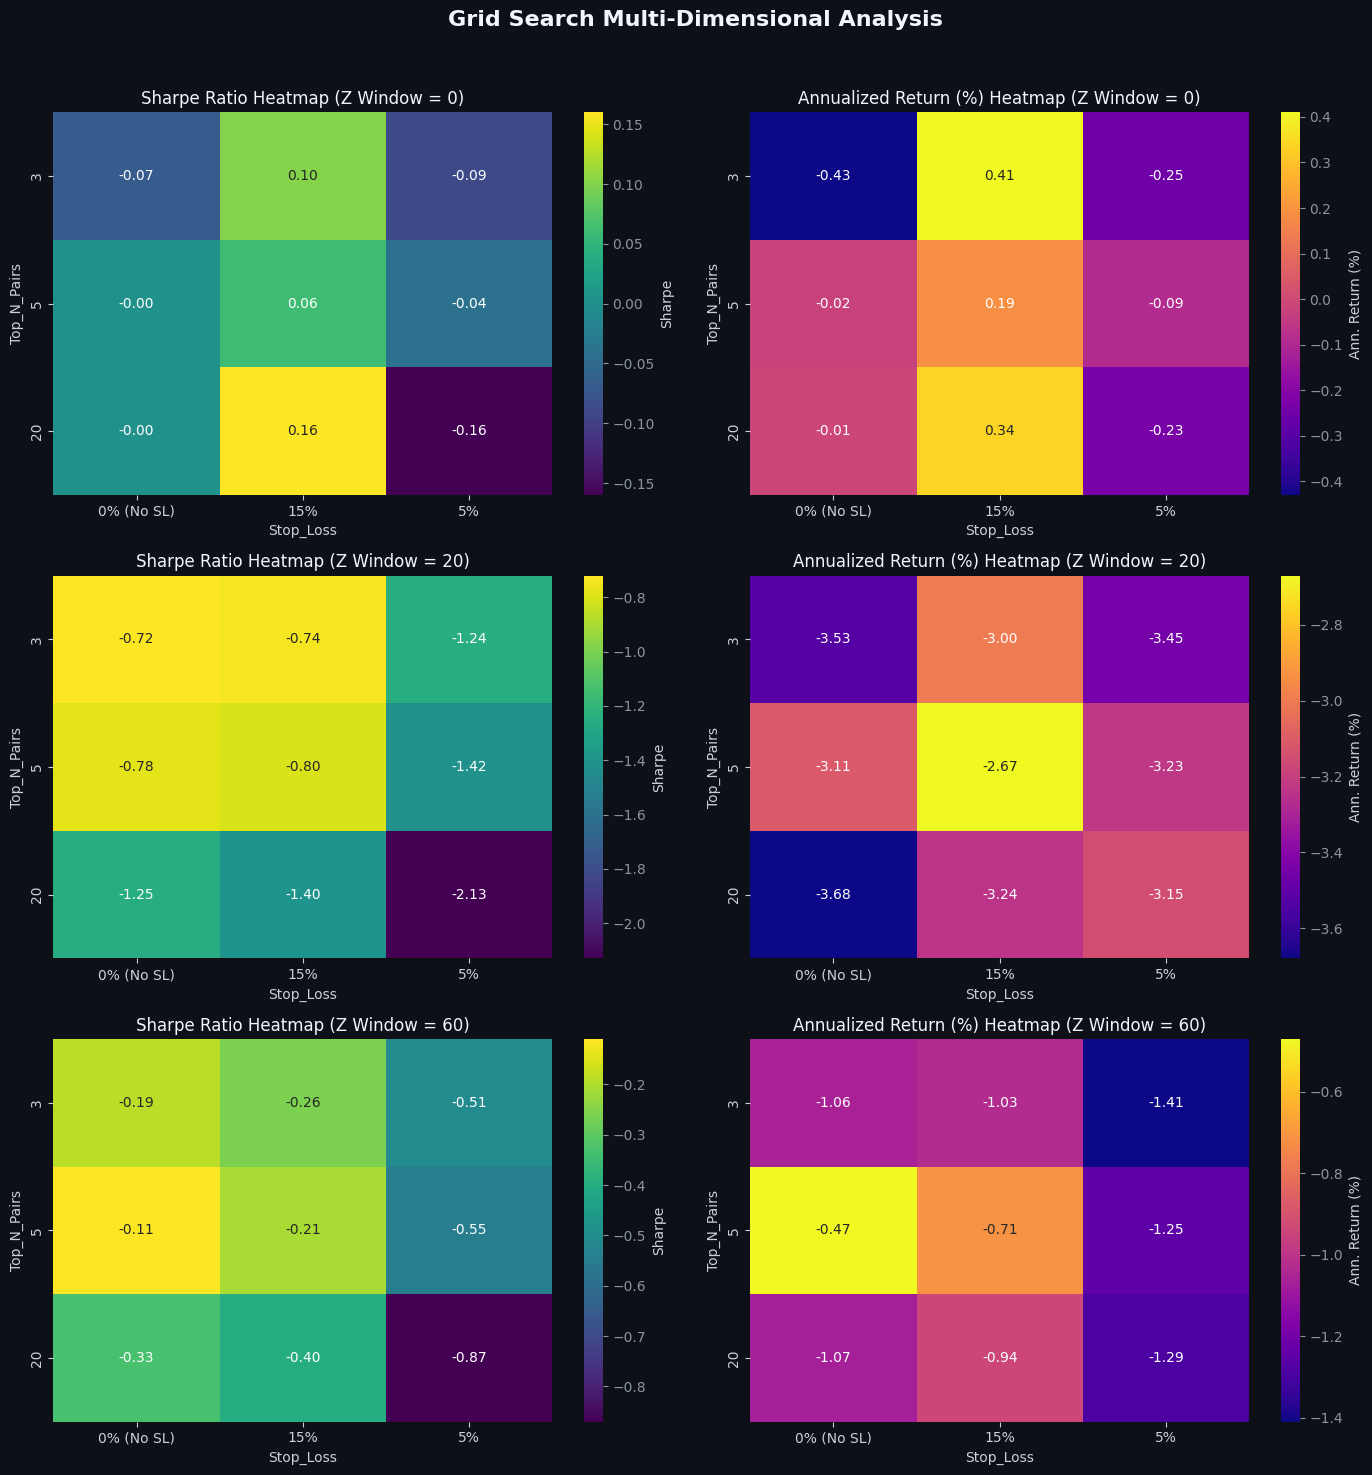

In [8]:
# ══════════════════════════════════════════════════════════════════════════════
# 主程式：自動參數網格搜尋 (Grid Search)
# ══════════════════════════════════════════════════════════════════════════════
if __name__ == "__main__":
    
    MIN_TICKERS_FOR_PAIRING = 2  
    ZSCORE_CLIP = 10.0           
    MIN_SPREAD_STD = 1e-6

    # DB_PATH, TABLE_NAME = r"../data/sp500.db", "daily_prices"
    # BACKTEST_START, BACKTEST_END = "2000-01", "2025-12"
    # INFO_TABLE_NAME, TICKER_COL_NAME, SECTOR_COL_NAME = "company_info", "ticker", "sector"

    DB_PATH, TABLE_NAME = r"../data/sp500_Current.db", "Daily_Prices"
    BACKTEST_START, BACKTEST_END = "2000-01", "2025-12"
    INFO_TABLE_NAME, TICKER_COL_NAME, SECTOR_COL_NAME = "Constituents", "Symbol", "GICS_Sector"
    
    TOP_N_LIST = [3, 5, 20]
    STOP_LOSS_LIST = [0, 0.05, 0.15]      # 0 表示不停損
    ZSCORE_WINDOW_LIST = [0, 20, 60]      # 0 表示固定 Z 值
    
    ENTRY_Z = 2.0 
    EXIT_Z = 0.0 
    
    FORMATION_WINDOW, TRADING_WINDOW, ROLLING_STEP = 252, 126, 21
    
    FEE_RATE = 0.001
    SLIPPAGE_RATE = 0.001 
    INITIAL_CAPITAL = 10000 
    
    ALLOW_REENTRY = False            
    USE_SECTOR_PAIRING = False       
    
    OUTPUT_DIR = Path(r"../results/SSDc_NoReEntry_NoSector")
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

    processor = DataProcessor(db_path=DB_PATH, table_name=TABLE_NAME)
    
    if USE_SECTOR_PAIRING:
        sector_mapping = processor.load_sector_mapping(INFO_TABLE_NAME, TICKER_COL_NAME, SECTOR_COL_NAME)
    else:
        sector_mapping = {}
        print("ℹ️ 產業分類配對已關閉 (USE_SECTOR_PAIRING = False)，系統將進行全市場全標的配對。")
        
    price_pivot, all_dates, total_days, local_first_trade_idx = processor.prepare_backtest_data(BACKTEST_START, BACKTEST_END, FORMATION_WINDOW)

    max_concurrent = TRADING_WINDOW // ROLLING_STEP
    states = {}
    
    for n, sl, z_win in itertools.product(TOP_N_LIST, STOP_LOSS_LIST, ZSCORE_WINDOW_LIST):
        sub_dir = OUTPUT_DIR / f"Top{n}_SL{int(sl*100)}_ZWin{z_win}"
        perf = Performance(initial_capital=INITIAL_CAPITAL, output_dir=sub_dir)
        perf.set_zscore_params(entry_z=ENTRY_Z, exit_z=EXIT_Z)
        states[(n, sl, z_win)] = {
            "perf": perf, 
            "slots": [{"avail_idx": 0, "capital": INITIAL_CAPITAL / max_concurrent} for _ in range(max_concurrent)]
        }

    roll_start_indices = list(range(local_first_trade_idx, total_days - TRADING_WINDOW + 1, ROLLING_STEP))
    print(f"\n🚀 開始進行 Grid Search，共 {len(roll_start_indices)} 期，每期處理 {len(states)} 種參數組合...")

    for roll_idx, trade_start_idx in enumerate(roll_start_indices):
        form_start_idx, form_end_idx = trade_start_idx - FORMATION_WINDOW, trade_start_idx
        trade_end_idx = min(trade_start_idx + TRADING_WINDOW, total_days)

        form_data = price_pivot.iloc[form_start_idx:form_end_idx]
        trade_data = price_pivot.iloc[trade_start_idx:trade_end_idx]
        valid_cols = (form_data.isnull().sum() + trade_data.isnull().sum()) == 0
        
        form_data = form_data.loc[:, valid_cols]
        trade_dates = trade_data.index
        
        extended_trade_start_idx = max(0, trade_start_idx - max(ZSCORE_WINDOW_LIST))
        extended_trade_data = price_pivot.iloc[extended_trade_start_idx:trade_end_idx].loc[:, valid_cols]

        if form_data.shape[1] < 2 or trade_data.empty: continue

        trade_start_str, trade_end_str = str(all_dates[trade_start_idx])[:10], str(all_dates[trade_end_idx - 1])[:10]
        form_start_str, form_end_str = str(all_dates[form_start_idx])[:10], str(all_dates[form_end_idx - 1])[:10]
        print(f"  ▶ 處理中：第 {roll_idx+1:02d} 期 (交易: {trade_start_str} ~ {trade_end_str})")

        formation = Formation(
            price_df=form_data, 
            form_start=form_start_str, 
            form_end=form_end_str, 
            top_n=max(TOP_N_LIST), 
            sector_mapping=sector_mapping,
            min_tickers_for_pairing=MIN_TICKERS_FOR_PAIRING
        )
        max_selected_pairs = formation.run()

        if max_selected_pairs.empty: continue

        for n, sl, z_win in itertools.product(TOP_N_LIST, STOP_LOSS_LIST, ZSCORE_WINDOW_LIST):
            selected_pairs = max_selected_pairs.head(n)
            state = states[(n, sl, z_win)]
            slots = state["slots"]
            
            free_slots = [i for i, s in enumerate(slots) if s["avail_idx"] <= trade_start_idx]
            if free_slots:
                slot_idx = free_slots[0]
            else:
                slot_idx = min(range(max_concurrent), key=lambda i: slots[i]["avail_idx"])

            current_period_capital = slots[slot_idx]["capital"]
            current_capital_per_pair = current_period_capital / n

            trading = Trading(
                price_df=extended_trade_data,
                trade_dates=trade_dates,
                selected_pairs=selected_pairs,
                capital_per_pair=current_capital_per_pair,
                fee_rate=FEE_RATE,
                slippage_rate=SLIPPAGE_RATE,
                stop_loss_pct=sl,
                entry_z=ENTRY_Z,
                exit_z=EXIT_Z,
                zscore_window=z_win,
                allow_reentry=ALLOW_REENTRY,
                zscore_clip=ZSCORE_CLIP,
                min_spread_std=MIN_SPREAD_STD
            )
            
            trade_log_df, period_daily_delta = trading.run()
            period_pnl = trading.period_pnl if not trade_log_df.empty else 0.0
            
            slots[slot_idx]["capital"] = max(0, current_period_capital + period_pnl)
            slots[slot_idx]["avail_idx"] = trade_end_idx
            
            state["perf"].add_period(trade_start_str, trade_end_str, trade_log_df, period_daily_delta, current_period_capital, current_capital_per_pair)

    summary_results = []
    print("\n✅ 回測完成！正在產生總結報表...")
    for (n, sl, z_win), state in states.items():
        report = state["perf"].generate_report(quiet=True)
        if report:
            report["Z_Window"] = z_win
            report["Top_N_Pairs"] = n
            report["Stop_Loss"] = f"{sl*100:.0f}%" if sl > 0 else "0% (No SL)"
            summary_results.append(report)

    if not summary_results:
        print("⚠️ 無有效交易紀錄，請檢查資料或參數設定。")
    else:
        summary_df = pd.DataFrame(summary_results)
        cols = ["Z_Window", "Top_N_Pairs", "Stop_Loss", "Annualized Return (%)", "Sharpe Ratio", "Max Drawdown (%)", "Period Win Rate (%)", "Trade Win Rate (%)", "Total Trades", "Stop Losses", "Forced Exits", "Avg Payoff Ratio", "Avg R_EC (%)"]
        summary_df = summary_df[cols].sort_values("Sharpe Ratio", ascending=False)
        summary_df.to_csv(OUTPUT_DIR / "grid_search_summary.csv", index=False)

        plt.rcParams.update({"figure.facecolor": "#0d1117", "axes.facecolor": "#161b22", "text.color": "#c9d1d9"})
        fig, axes = plt.subplots(len(ZSCORE_WINDOW_LIST), 2, figsize=(14, 5 * len(ZSCORE_WINDOW_LIST)), squeeze=False)
        fig.patch.set_facecolor("#0d1117")

        for idx, z_win in enumerate(ZSCORE_WINDOW_LIST):
            df_sub = summary_df[summary_df["Z_Window"] == z_win]
            if df_sub.empty: continue
            
            pivot_sharpe = df_sub.pivot(index="Top_N_Pairs", columns="Stop_Loss", values="Sharpe Ratio")
            pivot_ann_ret = df_sub.pivot(index="Top_N_Pairs", columns="Stop_Loss", values="Annualized Return (%)")

            sns.heatmap(pivot_sharpe, annot=True, cmap="viridis", ax=axes[idx, 0], cbar_kws={'label': 'Sharpe'}, fmt=".2f")
            axes[idx, 0].set_title(f"Sharpe Ratio Heatmap (Z Window = {z_win})", color="#f0f6fc")
            axes[idx, 0].tick_params(colors="#c9d1d9")

            sns.heatmap(pivot_ann_ret, annot=True, cmap="plasma", ax=axes[idx, 1], cbar_kws={'label': 'Ann. Return (%)'}, fmt=".2f")
            axes[idx, 1].set_title(f"Annualized Return (%) Heatmap (Z Window = {z_win})", color="#f0f6fc")
            axes[idx, 1].tick_params(colors="#c9d1d9")

        plt.suptitle(f"Grid Search Multi-Dimensional Analysis", color="#f0f6fc", fontsize=16, fontweight="bold")
        plt.tight_layout(rect=[0, 0, 1, 0.96])
        
        heatmap_file = OUTPUT_DIR / "grid_search_heatmap.png"
        fig.savefig(heatmap_file, dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
        
        plt.show()